In [1]:
using IonSim
using QuantumOptics
using PyPlot

function plot_wigner(final_state)
    rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(20)
rho_fock = DenseOperator(b_fock, rho_motional.data)

x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W = wigner(rho_fock, x_vec, p_vec)

fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)
end


function SDF_apply_with_alpha(angle = 0, time = 50.0, cat_state = false, initial_state = nothing)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle

    if (cat_state)
        println("Preparing cat state superposition...")
        red_angle = -angle
        blue_angle = angle
    end
    trap_freq = 19e5 # 1 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 20
    mode_z.shape = [21]

   k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e6 # Adjust this to push the ion faster/slower
    B_field = 1e-13
    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap)

    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    println(mode)

    ψ_ion = normalize(ion["g"] -  ion["e"])

    
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        println("Using provided initial state...")
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    tspan = 0:0.5:time 
    println("Simulating bichromatic displacement...")
    tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

    final_state = sol[end]

    # ---------------------------------------------------------
# 1. Fundamental Physics Constants
# ---------------------------------------------------------
 hbar = 1.0545718e-34       # Reduced Planck constant (J*s)
 amu = 1.66053906e-27       # Atomic mass unit (kg)
 m_Ca40 = 39.96259 * amu    # Mass of Calcium-40 ion (kg)
 c = 2.99792458e8           # Speed of light (m/s)

# ---------------------------------------------------------
# 2. Your Simulated Experiment Parameters
# ---------------------------------------------------------     
wavelength = transition_λ             # Quadrupole transition wavelength (m)
tspan_end = time * 1e-6              # Total laser interaction time (s)
# ---------------------------------------------------------
# 3. Step-by-Step Calculation
# ---------------------------------------------------------

println("--- VERIFYING DISPLACEMENT PARAMETERS ---")

# Step A: Zero-Point Fluctuation (z_zpf)
# z_zpf = sqrt( ħ / (2 * m * ω_trap) )
omega_trap = 2 * π * trap_freq
z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
println("Zero-Point Fluctuation (z_zpf) : ", round(z_zpf * 1e9, digits=4), " nm")

# Step B: Wavevector Z-Projection (k_z)
# Your vector: k_vec = (x̂ + ẑ) / √2 
# Therefore, projection onto Z is 1/√2
k_total = 2 * π / wavelength
k_z = k_total / sqrt(2)
println("Z-Projected Wavevector (k_z)   : ", round(k_z, digits=2), " m⁻¹")

# Step C: Lamb-Dicke Parameter (η)
# η = k_z * z_zpf
eta = k_z * z_zpf
println("Lamb-Dicke Parameter (η)       : ", round(eta, digits=4))

# Step D: Effective Rabi Frequency (Ω_eff)
# The geometric coupling factor for a Δm=0 quadrupole transition using your 
# specific k_vec and ϵ_vec vectors results in a scaling reduction of 1/4.
# geometric_factor = 1.0 / 4.0
geometric_factor = 1.0 / ( sqrt(3)) 

# STRETCHED STATE: The CG coefficient is exactly 1.0! 
cg_factor = 1.0 # The Clebsch-Gordan factor for Δm=0 in Ca40

# The true effective Rabi frequency acting on the ion's orbitals
Omega_eff = laser_intensity * geometric_factor * cg_factor
println("Effective Rabi Freq (Ω_eff)    : ", Omega_eff, " rad/s")

# Step E: Displacement Magnitude (|α|)
# |α| = 1/2 * η * Ω_eff * t 
alpha_mag = 0.5 * eta * Omega_eff * tspan_end 

println("-----------------------------------------")
println("FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : ", round(alpha_mag, digits=3))
println("-----------------------------------------")
return final_state
end

trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 20
    mode_z.shape = [21]

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e6 # Fixed intensity
    B_field = 1e-13
    
    # Pre-build a trap just to grab the transition wavelength
    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap)
    mode = zmodes(trap)[1]
    println(mode)
    ψ_ion = normalize(ion["g"] - ion["e"])
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

    # 1. Grab the exact mode object used in the simulation (no generic FockBasis!)
sim_mode = zmodes(trap)[1]
a = 0.716 * im 

# 2. Build the displacement operator using the IonSim mode
# IonSim has a built-in displace() method specifically for VibrationalModes
D_motion = IonSim.displace(sim_mode, a)

# 3. Create a "Do Nothing" operator for the ion's spin
I_spin = identityoperator(ion["g"].basis)

 ψ_ion = normalize(ion["g"] -  ion["e"])

# 4. Combine them into a full system operator (Spin ⊗ Motion)
D_system = identityoperator(ψ_ion.basis) ⊗ D_motion

# 5. Apply the operator to the state (The bases now match perfectly!)
displaced_final_state = D_system * ψ_initial

println(displaced_final_state)

function SDF_apply_with_alpha(angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing, fock_state_n = 0)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle

    if (cat_state)
        # println("Preparing cat state superposi/tion...")
        red_angle = -angle
        blue_angle = angle
    end
    
    trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 20
    mode_z.shape = [21]

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e4 # Fixed intensity
    B_field = 1e-13
    
    # Pre-build a trap just to grab the transition wavelength
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)

    # ---------------------------------------------------------
    # NEW: DYNAMIC TIME CALCULATION VIA WIGNER-ECKART ENGINE
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    c = 2.99792458e8           

    # 1. Calculate Lamb-Dicke Parameter (η) dynamically
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    # 2. Hijack IonSim's internal matrix element calculator
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    # Feed the dummy laser into the exact internal physics engine
    # (Note: Unexported internal functions need the module prefix 'IonSim.')
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    # 3. Solve the displacemen formula backward to find exactly how long to leave the lasers on
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    target_time_us = target_time_s * 1e6
    # ---------------------------------------------------------

    # Now build the actual lasers and final chamber
    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    # println(mode)

    ψ_ion = normalize(ion["g"] - ion["e"])
    ψ_mode = fockstate(mode, fock_state_n)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    
    # Ensure our solver array steps exactly up to our calculated target time
    tspan_array = collect(0:0.5:target_time_us)
    if tspan_array[end] < target_time_us
        push!(tspan_array, target_time_us)
    end

    tout, sol = timeevolution.schroedinger_dynamic(tspan_array, ψ_initial, h)

    final_state = sol[end]
    
    return final_state
end

function protocol(initialstate = nothing, beta = 1, alpha = 0.5)

    beta_state = SDF_apply_with_alpha(0, beta, false, initialstate, 0)
    final_state = SDF_apply_with_alpha(pi/2, alpha, true, beta_state, 0)

    return final_state
end

using LinearAlgebra

function calculate_qcrb(state, state_perturbed, d_alpha::Float64; tol=1e-10)
    
    # 1. Promote pure states (Ket) to density matrices
    rho1 = isa(state, Ket) ? dm(state) : state
    rho2 = isa(state_perturbed, Ket) ? dm(state_perturbed) : state_perturbed
    
    # 2. Extract dense data
    rho_dense_data = dense(rho1).data
    rho_pert_dense_data = dense(rho2).data

    # 3. Finite difference derivative
    drho_data = (rho_pert_dense_data - rho_dense_data) / d_alpha
    
    # 4. Use Hermitian() to guarantee real eigenvalues and speed up diagonalization
    λ, V = LinearAlgebra.eigen(Hermitian(rho_dense_data))
    
    qfi = 0.0
    n = length(λ)
    
    for i in 1:n
        for j in 1:n
            if real(λ[i] + λ[j]) > tol
                # 5. Use @views to prevent memory allocation during column slicing
                @views v_i = V[:, i]
                @views v_j = V[:, j]
                
                drho_ij = dot(v_i, drho_data * v_j)
                qfi += 2 * (abs(drho_ij)^2) / real(λ[i] + λ[j])
            end
        end
    end
    
    qcrb = qfi > 0 ? 1.0 / qfi : Inf
    return qfi, qcrb
end


VibrationalMode(ν=1.9e6, axis=ẑ, N=20)
Ket(dim=42)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=20)]
     0.54722151763696 + 0.0im
    -0.54722151763696 + 0.0im
                  0.0 + 0.3918106066280634im
                  0.0 - 0.3918106066280634im
  -0.1983691868114632 + 0.0im
   0.1983691868114632 + 0.0im
                  0.0 - 0.08200240843764023im
                  0.0 + 0.08200240843764023im
   0.0293568622206752 + 0.0im
  -0.0293568622206752 + 0.0im
                  0.0 + 0.0094002121409144im
                  0.0 - 0.0094002121409144im
 -0.00274773630415258 + 0.0im
  0.00274773630415258 + 0.0im
                  0.0 - 0.00074359944018383im
                  0.0 + 0.00074359944018383im
   0.0001882379059773 + 0.0im
  -0.0001882379059773 + 0.0im
                  0.0 + 4.492611355992e-5im
                  0.0 - 4.492611355992e-5im
   -1.017212932124e-5 + 0.0im
    1.017212932124e-5 + 0.0im
                  0.0 - 2.19598087043e-6im
                  0.0 + 2.195980870

calculate_qcrb (generic function with 1 method)

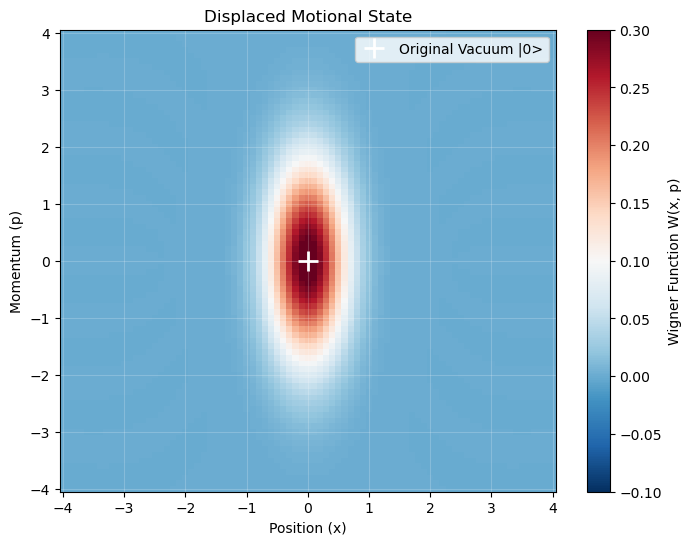

In [6]:
cutoff = 20
b = FockBasis(cutoff)
vac = fockstate(b, 0)

# 2. Define squeeze parameter z (z = r * exp(i * theta))
z = 0.5 * exp(1im * pi) 

# 3. Create the squeezed state by applying the squeeze operator to the vacuum
squeeze_op = squeeze(b, z)
squeezed_vac = squeeze_op * vac

state = ψ_ion ⊗ squeezed_vac

plot_wigner(state)

Simulating Fock State |0⟩ (Ancilla Readout)...
Beta: 0.01 μs, Fock |0⟩, QCRB: 631.2804651034652
Beta: 0.06 μs, Fock |0⟩, QCRB: 17.853317960472243
Beta: 0.11 μs, Fock |0⟩, QCRB: 5.480696619445355
Beta: 0.16 μs, Fock |0⟩, QCRB: 2.7366460232628054
Beta: 0.21 μs, Fock |0⟩, QCRB: 1.7067531376906622
Beta: 0.26 μs, Fock |0⟩, QCRB: 1.2222911786859958
Beta: 0.31 μs, Fock |0⟩, QCRB: 0.9620008158741804
Beta: 0.36 μs, Fock |0⟩, QCRB: 0.8140242674113498
Beta: 0.41 μs, Fock |0⟩, QCRB: 0.730716001992581
Beta: 0.46 μs, Fock |0⟩, QCRB: 0.689116207868187
Beta: 0.51 μs, Fock |0⟩, QCRB: 0.6789473672891637
Beta: 0.56 μs, Fock |0⟩, QCRB: 0.695545159072008
Beta: 0.61 μs, Fock |0⟩, QCRB: 0.7385048533548646
Beta: 0.66 μs, Fock |0⟩, QCRB: 0.8106020910282363
Beta: 0.71 μs, Fock |0⟩, QCRB: 0.9183011534542179
Beta: 0.76 μs, Fock |0⟩, QCRB: 1.071108067235525
Beta: 0.81 μs, Fock |0⟩, QCRB: 1.2863343910699536
Beta: 0.86 μs, Fock |0⟩, QCRB: 1.586894629072432
Beta: 0.91 μs, Fock |0⟩, QCRB: 2.011107225018214
Beta: 0.96 

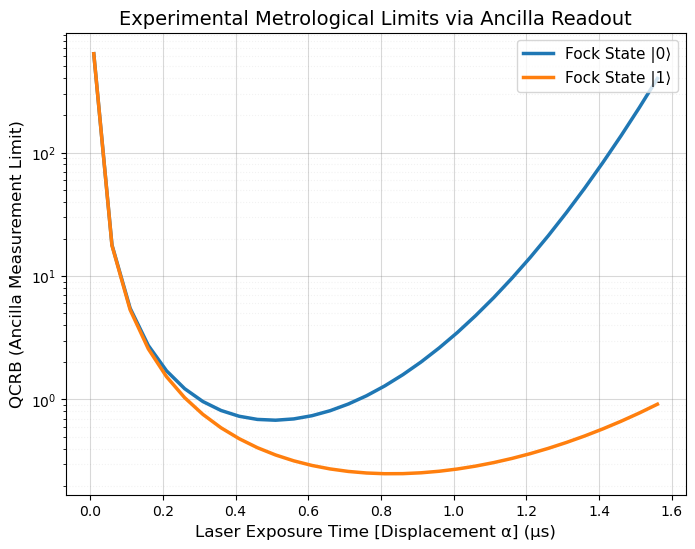

In [24]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Ancilla Qubit Readout (Corrected)
# ---------------------------------------------------------
t_max = 1.6
time_steps = 0.01:0.05:t_max 
states = 0:1 
ψ_ion = normalize(ion["g"] - ion["e"])
# Infinitesimal mathematical signal
d_alpha = 0.01

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

# Pre-build the signal operator once to save loop time
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, im* d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal


for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    if (n == 0)
        ψ_mode = fockstate(mode, 0)
    else
       temp_fock_basis = FockBasis(sim_mode.N)
        z = 0.5 * exp(1im * pi) 
        S_fock = squeeze(temp_fock_basis, z) 
        squeeze_op = DenseOperator(sim_mode, sim_mode, S_fock.data)
        vac = fockstate(sim_mode, 0)
        ψ_mode = squeeze_op * vac
    end
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: Create the perturbed initial state
    ψ_initial_perturbed = D_system * ψ_initial
    
    println("Simulating Fock State |", n, "⟩ (Ancilla Readout)...")
    
    for (j, t) in enumerate(time_steps)
        # 1. Base Trajectory (No Signal)
        sol1 = protocol(ψ_initial, 1, t)
        ancilla_base = ptrace(sol1, 2) 

        finalstate = sol1
        
        # 2. Perturbed Trajectory (Signal happened before SDF readout)
        sol2 = protocol(ψ_initial_perturbed, 1, t)
        ancilla_perturbed = ptrace(sol2, 2)

        finalstate_perturbed = sol2

        # 3. Calculate true Ancilla QCRB
        qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[i, j] = qcrb
        println("Beta: ", round(t, digits=2), " μs, Fock |", n, "⟩, QCRB: ", qcrb)
    end

    PyPlot.plot(time_steps, qcrb_values, label="Fock State |$n⟩", linewidth=2.5, linestyle="-")
end

PyPlot.yscale("log")
# We can now confidently constrain the Y-axis to relevant physical limits

PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Experimental Metrological Limits via Ancilla Readout", fontsize=14)
PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

In [20]:
 cutoff = 20
        b = FockBasis(cutoff)
        vac = fockstate(sim_mode, 0)
        z = 0.5 * exp(1im * pi) 
        squeeze_op = squeeze(sim_mode, z)
        ψ_mode = squeeze_op * vac
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: Create the perturbed initial state
    ψ_initial_perturbed = D_system * ψ_initial

MethodError: MethodError: no method matching squeeze(::VibrationalMode, ::ComplexF64)
The function `squeeze` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  squeeze(!Matched::SpinBasis, ::T) where T<:Number
   @ QuantumOpticsBase C:\Users\jewoo\.julia\packages\QuantumOpticsBase\u7a0b\src\spin.jl:120
  squeeze(!Matched::FockBasis, ::T) where T<:Number
   @ QuantumOpticsBase C:\Users\jewoo\.julia\packages\QuantumOpticsBase\u7a0b\src\fock.jl:76
  squeeze(!Matched::Type{T}, !Matched::SpinBasis, !Matched::Number) where T
   @ QuantumOpticsBase C:\Users\jewoo\.julia\packages\QuantumOpticsBase\u7a0b\src\spin.jl:113
  ...


In [23]:
sim_mode = zmodes(trap)[1]
    
    # 1. Create a temporary standard FockBasis of the EXACT same dimension
    temp_fock_basis = FockBasis(sim_mode.N)
    
    # 2. Use QuantumOptics to calculate the complex squeeze matrix
    z = 0.5 * exp(1im * pi) 
    S_fock = squeeze(temp_fock_basis, z) 
    
    # 3. THE FIX: Wrap the raw matrix data back into the IonSim mode!
    squeeze_op = DenseOperator(sim_mode, sim_mode, S_fock.data)
    
    # 4. Build the vacuum state directly on the IonSim mode
    vac = fockstate(sim_mode, 0)
    
    # 5. Apply the wrapped squeeze operator
    ψ_mode = squeeze_op * vac
    
    # 6. Tensor the spin and the mode together
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # NOW APPLY SIGNAL: The dimensions and types match perfectly!
    ψ_initial_perturbed = D_system * ψ_initial

Ket(dim=42)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=20)]
   0.6658412836923923 + 0.0im
  -0.6658412836923923 - 0.0im
                  0.0 + 0.00973537964896454im
                 -0.0 - 0.00973537964896454im
  0.21747375837055205 - 3.0e-17im
 -0.21747375837055205 + 3.0e-17im
                  0.0 + 0.00550913786423412im
                 -0.0 - 0.00550913786423412im
  0.08699385347779022 - 2.0e-17im
 -0.08699385347779022 + 2.0e-17im
                      ⋮
    -0.00061454539498 + 0.0im
                  0.0 + 3.667166195171e-5im
                 -0.0 - 3.667166195171e-5im
   0.0002648475541853 - 0.0im
  -0.0002648475541853 + 0.0im
                  0.0 + 1.823944967897e-5im
                 -0.0 - 1.823944967897e-5im
  0.00014866880846163 - 0.0im
 -0.00014866880846163 + 0.0im

Simulating Ordinary Vacuum |0⟩...
Beta: 0.01 μs, State: Vacuum, QCRB: 631.2804651034652
Beta: 0.06 μs, State: Vacuum, QCRB: 17.853317960472243
Beta: 0.11 μs, State: Vacuum, QCRB: 5.480696619445355
Beta: 0.16 μs, State: Vacuum, QCRB: 2.7366460232628054
Beta: 0.21 μs, State: Vacuum, QCRB: 1.7067531376906622
Beta: 0.26 μs, State: Vacuum, QCRB: 1.2222911786859958
Beta: 0.31 μs, State: Vacuum, QCRB: 0.9620008158741804
Beta: 0.36 μs, State: Vacuum, QCRB: 0.8140242674113498
Beta: 0.41 μs, State: Vacuum, QCRB: 0.730716001992581
Beta: 0.46 μs, State: Vacuum, QCRB: 0.689116207868187
Beta: 0.51 μs, State: Vacuum, QCRB: 0.6789473672891637
Beta: 0.56 μs, State: Vacuum, QCRB: 0.695545159072008
Beta: 0.61 μs, State: Vacuum, QCRB: 0.7385048533548646
Beta: 0.66 μs, State: Vacuum, QCRB: 0.8106020910282363
Beta: 0.71 μs, State: Vacuum, QCRB: 0.9183011534542179
Beta: 0.76 μs, State: Vacuum, QCRB: 1.071108067235525
Beta: 0.81 μs, State: Vacuum, QCRB: 1.2863343910699536
Beta: 0.86 μs, State: Vacuum, QCRB: 1

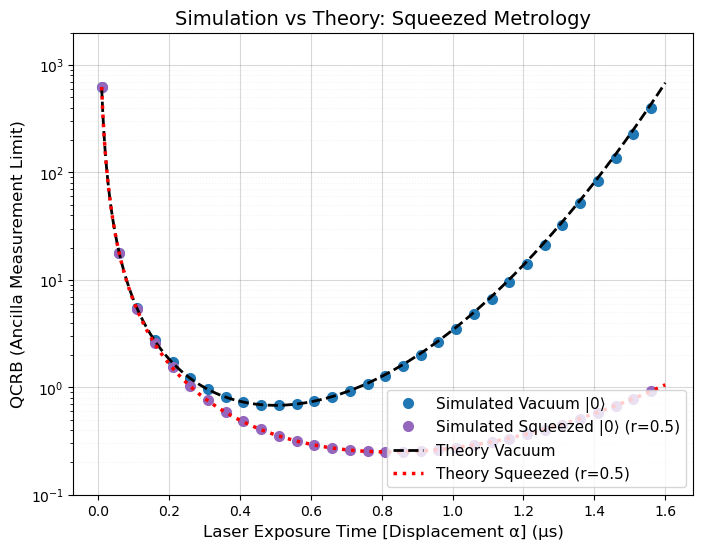

In [ ]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Squeezed vs Vacuum
# ---------------------------------------------------------
t_max = 1.6
time_steps = 0.01:0.05:t_max 
states = 0:1 
ψ_ion = normalize(ion["g"] - ion["e"])
d_alpha = 0.01

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

# Pre-build the signal operator once to save loop time
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, im * d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal

# Squeezing parameter
r_squeeze = 0.5

for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    if n == 0
        println("Simulating Ordinary Vacuum |0⟩...")
        ψ_mode = fockstate(sim_mode, 0)
        label_sim = "Simulated Vacuum |0⟩"
        color_sim = "tab:blue"
    else
        println("Simulating Squeezed Vacuum (r = $r_squeeze)...")
        # 1. Trick QuantumOptics into calculating the matrix
        temp_fock_basis = FockBasis(sim_mode.N)
        
        # 2. Squeeze in momentum (anti-squeeze in position)
        z = r_squeeze * exp(1im * pi) 
        S_fock = squeeze(temp_fock_basis, z) 
        
        # 3. Wrap it back into IonSim
        squeeze_op = DenseOperator(sim_mode, sim_mode, S_fock.data)
        vac = fockstate(sim_mode, 0)
        ψ_mode = squeeze_op * vac
        
        label_sim = "Simulated Squeezed |0⟩ (r=$r_squeeze)"
        color_sim = "tab:purple"
    end
    
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: Create the perturbed initial state
    ψ_initial_perturbed = D_system * ψ_initial
    
    for (j, t) in enumerate(time_steps)
        # 1. Base Trajectory (No Signal)
        sol1 = protocol(ψ_initial, 1, t)
        ancilla_base = ptrace(sol1, 2) 
        
        # 2. Perturbed Trajectory (Signal happened before SDF readout)
        sol2 = protocol(ψ_initial_perturbed, 1, t)
        ancilla_perturbed = ptrace(sol2, 2)
        
        # 3. Calculate true Ancilla QCRB
        qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[i, j] = qcrb
        println("Beta: ", round(t, digits=2), " μs, State: ", n==0 ? "Vacuum" : "Squeezed", ", QCRB: ", qcrb)
    end
    
    # Plot simulation as scatter dots
    PyPlot.plot(time_steps, qcrb_values, "o", color=color_sim, markersize=7, label=label_sim)
end

# ---------------------------------------------------------
# Analytical Theory Overlay
# ---------------------------------------------------------
# High-resolution X-axis to capture smooth curves
alphas_theory = range(0.01, stop=t_max, length=1000)

# 1. Theory for Ordinary Vacuum (r = 0)
# Formula: exp(4x^2) / (16x^2)
qcrb_theory_0 = @. exp(4 * alphas_theory^2) / (16 * alphas_theory^2 + 1e-15)

# 2. Theory for Squeezed Vacuum
# Because we used a phase of pi, the wavepacket is anti-squeezed (wider) in the X direction.
# This suppresses the wavepacket separation penalty by e^(-2r).
suppression_factor = exp(-2 * r_squeeze)
qcrb_theory_sq = @. exp(4 * alphas_theory^2 * suppression_factor) / (16 * alphas_theory^2 + 1e-15)

# Plot the pure analytical equations
PyPlot.plot(alphas_theory, qcrb_theory_0, "--", color="black", linewidth=2, label="Theory Vacuum")
PyPlot.plot(alphas_theory, qcrb_theory_sq, ":", color="red", linewidth=2.5, label="Theory Squeezed (r=$r_squeeze)")

# ---------------------------------------------------------
# Plot Formatting
# ---------------------------------------------------------
PyPlot.yscale("log")
PyPlot.ylim(1e-1, 2e3) # Confidently constrain the Y-axis so infinities don't compress the graph

PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Simulation vs Theory: Squeezed Metrology", fontsize=14)

# Put legend in the lower right so it doesn't cover the upper-left curves
PyPlot.legend(loc="lower right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

Simulating Ordinary Vacuum |1⟩...
Beta: 0.01 μs, State: Vacuum, QCRB: 635.5048649073302
Beta: 0.06 μs, State: Vacuum, QCRB: 18.46572195657832
Beta: 0.11 μs, State: Vacuum, QCRB: 6.075485042479804
Beta: 0.16 μs, State: Vacuum, QCRB: 3.4014549469930544
Beta: 0.21 μs, State: Vacuum, QCRB: 2.5131035102380057
Beta: 0.26 μs, State: Vacuum, QCRB: 2.2815526280535408
Beta: 0.31 μs, State: Vacuum, QCRB: 2.503246606219698
Beta: 0.36 μs, State: Vacuum, QCRB: 3.416254194454021
Beta: 0.41 μs, State: Vacuum, QCRB: 6.4303548830837
Beta: 0.46 μs, State: Vacuum, QCRB: 25.113476870716628
Beta: 0.51 μs, State: Vacuum, QCRB: 924.0332973025073
Beta: 0.56 μs, State: Vacuum, QCRB: 12.430203839980235
Beta: 0.61 μs, State: Vacuum, QCRB: 3.3848656768484973
Beta: 0.66 μs, State: Vacuum, QCRB: 1.5748755594554344
Beta: 0.71 μs, State: Vacuum, QCRB: 0.9397885711078935
Beta: 0.76 μs, State: Vacuum, QCRB: 0.6554021714610763
Beta: 0.81 μs, State: Vacuum, QCRB: 0.5089983908375653
Beta: 0.86 μs, State: Vacuum, QCRB: 0.43

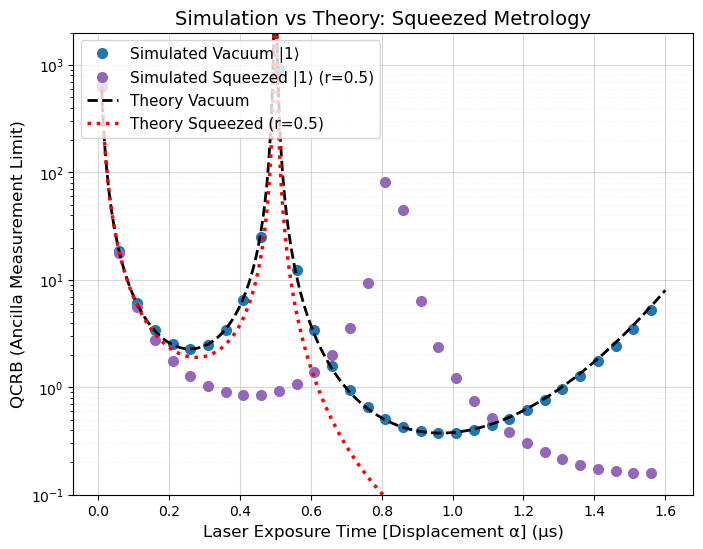

In [28]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Squeezed vs Vacuum
# ---------------------------------------------------------
t_max = 1.6
time_steps = 0.01:0.05:t_max 
states = 0:1 
ψ_ion = normalize(ion["g"] - ion["e"])
d_alpha = 0.01

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

# Pre-build the signal operator once to save loop time
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, im * d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal

# Squeezing parameter
r_squeeze = 0.5

for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    if n == 0
        println("Simulating Ordinary Vacuum |1⟩...")
        ψ_mode = fockstate(sim_mode, 1)
        label_sim = "Simulated Vacuum |1⟩"
        color_sim = "tab:blue"
    else
        println("Simulating Squeezed Vacuum (r = $r_squeeze)...")
        # 1. Trick QuantumOptics into calculating the matrix
        temp_fock_basis = FockBasis(sim_mode.N)
        
        # 2. Squeeze in momentum (anti-squeeze in position)
        z = r_squeeze * exp(1im * pi) 
        S_fock = squeeze(temp_fock_basis, z) 
        
        # 3. Wrap it back into IonSim
        squeeze_op = DenseOperator(sim_mode, sim_mode, S_fock.data)
        vac = fockstate(sim_mode, 1)
        ψ_mode = squeeze_op * vac
        
        label_sim = "Simulated Squeezed |1⟩ (r=$r_squeeze)"
        color_sim = "tab:purple"
    end
    
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: Create the perturbed initial state
    ψ_initial_perturbed = D_system * ψ_initial
    
    for (j, t) in enumerate(time_steps)
        # 1. Base Trajectory (No Signal)
        sol1 = protocol(ψ_initial, 1, t)
        ancilla_base = ptrace(sol1, 2) 
        
        # 2. Perturbed Trajectory (Signal happened before SDF readout)
        sol2 = protocol(ψ_initial_perturbed, 1, t)
        ancilla_perturbed = ptrace(sol2, 2)
        
        # 3. Calculate true Ancilla QCRB
        qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[i, j] = qcrb
        println("Beta: ", round(t, digits=2), " μs, State: ", n==0 ? "Vacuum" : "Squeezed", ", QCRB: ", qcrb)
    end
    
    # Plot simulation as scatter dots
    PyPlot.plot(time_steps, qcrb_values, "o", color=color_sim, markersize=7, label=label_sim)
end

# ---------------------------------------------------------
# Analytical Theory Overlay
# ---------------------------------------------------------
# High-resolution X-axis to capture smooth curves
alphas_theory = range(0.01, stop=t_max, length=1000)

# 1. Theory for Ordinary Vacuum (r = 0)
# Formula: exp(4x^2) / (16x^2)
qcrb_theory_0 = @. exp(4 * alphas_theory^2) / (16 * alphas_theory^2 * (1 - 4 * alphas_theory^2)^2 + 1e-15)

# 2. Theory for Squeezed Vacuum
# Because we used a phase of pi, the wavepacket is anti-squeezed (wider) in the X direction.
# This suppresses the wavepacket separation penalty by e^(-2r).
suppression_factor = exp(-2 * r_squeeze)
qcrb_theory_sq = @. exp(4 * alphas_theory^2 * suppression_factor) / (16 * alphas_theory^2 * (1 - 4 * alphas_theory^2)^2 + 1e-15)

# Plot the pure analytical equations
PyPlot.plot(alphas_theory, qcrb_theory_0, "--", color="black", linewidth=2, label="Theory Vacuum")
PyPlot.plot(alphas_theory, qcrb_theory_sq, ":", color="red", linewidth=2.5, label="Theory Squeezed (r=$r_squeeze)")

# ---------------------------------------------------------
# Plot Formatting
# ---------------------------------------------------------
PyPlot.yscale("log")
PyPlot.ylim(1e-1, 2e3) # Confidently constrain the Y-axis so infinities don't compress the graph

PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Simulation vs Theory: Squeezed Metrology", fontsize=14)

# Put legend in the lower left so it doesn't cover the data curves
PyPlot.legend(loc="upper left", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

Simulating Squeezed Vacuum (r = 0.0)...
Beta: 0.01 μs, State: Squeezed, QCRB: 631.2804651034652
Beta: 0.06 μs, State: Squeezed, QCRB: 17.853317960472243
Beta: 0.11 μs, State: Squeezed, QCRB: 5.480696619445355
Beta: 0.16 μs, State: Squeezed, QCRB: 2.7366460232628054
Beta: 0.21 μs, State: Squeezed, QCRB: 1.7067531376906622
Beta: 0.26 μs, State: Squeezed, QCRB: 1.2222911786859958
Beta: 0.31 μs, State: Squeezed, QCRB: 0.9620008158741804
Beta: 0.36 μs, State: Squeezed, QCRB: 0.8140242674113498
Beta: 0.41 μs, State: Squeezed, QCRB: 0.730716001992581
Beta: 0.46 μs, State: Squeezed, QCRB: 0.689116207868187
Beta: 0.51 μs, State: Squeezed, QCRB: 0.6789473672891637
Beta: 0.56 μs, State: Squeezed, QCRB: 0.695545159072008
Beta: 0.61 μs, State: Squeezed, QCRB: 0.7385048533548646
Beta: 0.66 μs, State: Squeezed, QCRB: 0.8106020910282363
Beta: 0.71 μs, State: Squeezed, QCRB: 0.9183011534542179
Beta: 0.76 μs, State: Squeezed, QCRB: 1.071108067235525
Beta: 0.81 μs, State: Squeezed, QCRB: 1.28633439106995

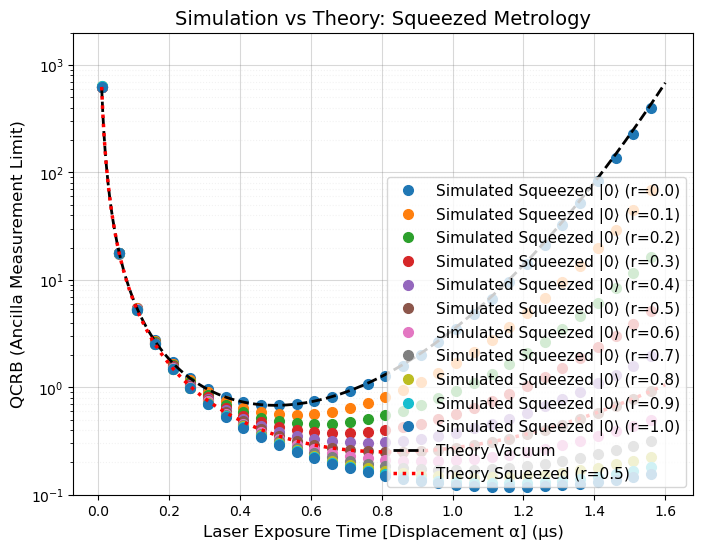

In [32]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Squeezed vs Vacuum
# ---------------------------------------------------------
t_max = 1.6
time_steps = 0.01:0.05:t_max 
states = 0:1 
ψ_ion = normalize(ion["g"] - ion["e"])
d_alpha = 0.01

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(time_steps))

# Pre-build the signal operator once to save loop time
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, im * d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal


r_squeezes = 0.0:0.1:1.0
 for r_squeeze in r_squeezes
    qcrb_values = Float64[]
    
 
       
    println("Simulating Squeezed Vacuum (r = $r_squeeze)...")
    # 1. Trick QuantumOptics into calculating the matrix
    temp_fock_basis = FockBasis(sim_mode.N)
    
    # 2. Squeeze in momentum (anti-squeeze in position)
    z = r_squeeze * exp(1im * pi) 
    S_fock = squeeze(temp_fock_basis, z) 
    
    # 3. Wrap it back into IonSim
    squeeze_op = DenseOperator(sim_mode, sim_mode, S_fock.data)
    vac = fockstate(sim_mode, 0)
    ψ_mode = squeeze_op * vac
    
    label_sim = "Simulated Squeezed |0⟩ (r=$r_squeeze)"
    color_sim = "tab:purple"

    
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: Create the perturbed initial state
    ψ_initial_perturbed = D_system * ψ_initial
    
    for (j, t) in enumerate(time_steps)
        # 1. Base Trajectory (No Signal)
        sol1 = protocol(ψ_initial, 1, t)
        ancilla_base = ptrace(sol1, 2) 
        
        # 2. Perturbed Trajectory (Signal happened before SDF readout)
        sol2 = protocol(ψ_initial_perturbed, 1, t)
        ancilla_perturbed = ptrace(sol2, 2)
        
        # 3. Calculate true Ancilla QCRB
        qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[j] = qcrb
        println("Beta: ", round(t, digits=2), " μs, State: ",  "Squeezed", ", QCRB: ", qcrb)
    end
    
    # Plot simulation as scatter dots
    PyPlot.plot(time_steps, qcrb_values, "o", markersize=7, label=label_sim)
end

# ---------------------------------------------------------
# Analytical Theory Overlay
# ---------------------------------------------------------
# High-resolution X-axis to capture smooth curves
alphas_theory = range(0.01, stop=t_max, length=1000)

# 1. Theory for Ordinary Vacuum (r = 0)
# Formula: exp(4x^2) / (16x^2)
qcrb_theory_0 = @. exp(4 * alphas_theory^2) / (16 * alphas_theory^2 + 1e-15)

# 2. Theory for Squeezed Vacuum
# Because we used a phase of pi, the wavepacket is anti-squeezed (wider) in the X direction.
# This suppresses the wavepacket separation penalty by e^(-2r).
suppression_factor = exp(-2 * r_squeeze)
qcrb_theory_sq = @. exp(4 * alphas_theory^2 * suppression_factor) / (16 * alphas_theory^2 + 1e-15)

# Plot the pure analytical equations
PyPlot.plot(alphas_theory, qcrb_theory_0, "--", color="black", linewidth=2, label="Theory Vacuum")
PyPlot.plot(alphas_theory, qcrb_theory_sq, ":", color="red", linewidth=2.5, label="Theory Squeezed (r=$r_squeeze)")

# ---------------------------------------------------------
# Plot Formatting
# ---------------------------------------------------------
PyPlot.yscale("log")
PyPlot.ylim(1e-1, 2e3) # Confidently constrain the Y-axis so infinities don't compress the graph

PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Simulation vs Theory: Squeezed Metrology", fontsize=14)

# Put legend in the lower right so it doesn't cover the upper-left curves
PyPlot.legend(loc="lower right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

Simulating Ordinary Fock |1⟩...
Beta: 0.01 μs, State: Ordinary, QCRB: 635.5048649073302
Beta: 0.06 μs, State: Ordinary, QCRB: 18.46572195657832
Beta: 0.11 μs, State: Ordinary, QCRB: 6.075485042479804
Beta: 0.16 μs, State: Ordinary, QCRB: 3.4014549469930544
Beta: 0.21 μs, State: Ordinary, QCRB: 2.5131035102380057
Beta: 0.26 μs, State: Ordinary, QCRB: 2.2815526280535408
Beta: 0.31 μs, State: Ordinary, QCRB: 2.503246606219698
Beta: 0.36 μs, State: Ordinary, QCRB: 3.416254194454021
Beta: 0.41 μs, State: Ordinary, QCRB: 6.4303548830837
Beta: 0.46 μs, State: Ordinary, QCRB: 25.113476870716628
Beta: 0.51 μs, State: Ordinary, QCRB: 924.0332973025073
Beta: 0.56 μs, State: Ordinary, QCRB: 12.430203839980235
Beta: 0.61 μs, State: Ordinary, QCRB: 3.3848656768484973
Beta: 0.66 μs, State: Ordinary, QCRB: 1.5748755594554344
Beta: 0.71 μs, State: Ordinary, QCRB: 0.9397885711078935
Beta: 0.76 μs, State: Ordinary, QCRB: 0.6554021714610763
Beta: 0.81 μs, State: Ordinary, QCRB: 0.5089983908375653
Beta: 0.

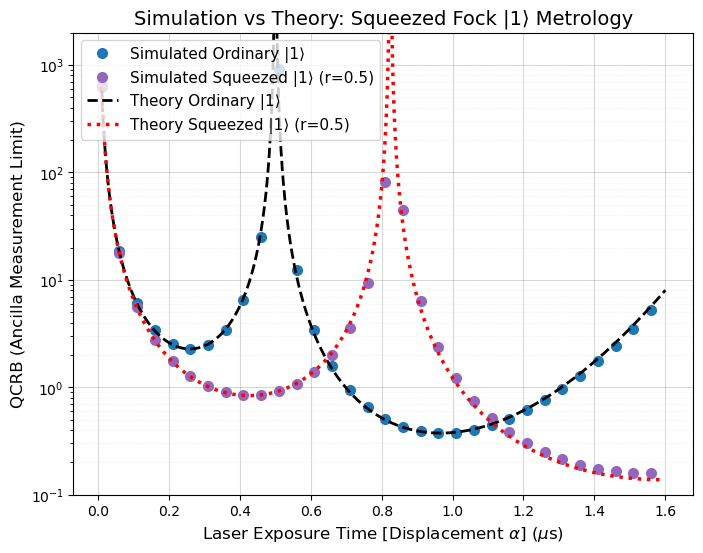

In [33]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Squeezed vs Ordinary Fock |1⟩
# ---------------------------------------------------------
t_max = 1.6
time_steps = 0.01:0.05:t_max 
state_types = ["Ordinary", "Squeezed"] 
ψ_ion = normalize(ion["g"] - ion["e"])
d_alpha = 0.01

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(state_types), length(time_steps))

# Pre-build the signal operator once to save loop time
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, im * d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal

# Squeezing parameter
r_squeeze = 0.5

for (i, state_type) in enumerate(state_types)
    qcrb_values = Float64[]
    
    if state_type == "Ordinary"
        println("Simulating Ordinary Fock |1⟩...")
        ψ_mode = fockstate(sim_mode, 1)
        label_sim = "Simulated Ordinary |1⟩"
        color_sim = "tab:blue"
    else
        println("Simulating Squeezed Fock |1⟩ (r = $r_squeeze)...")
        # 1. Trick QuantumOptics into calculating the matrix
        temp_fock_basis = FockBasis(sim_mode.N)
        
        # 2. Squeeze in momentum (anti-squeeze in position)
        z = r_squeeze * exp(1im * pi) 
        S_fock = squeeze(temp_fock_basis, z) 
        
        # 3. Wrap it back into IonSim
        squeeze_op = DenseOperator(sim_mode, sim_mode, S_fock.data)
        
        # Apply squeeze operator to Fock state |1>
        fock_1 = fockstate(sim_mode, 1)
        ψ_mode = squeeze_op * fock_1
        
        label_sim = "Simulated Squeezed |1⟩ (r=$r_squeeze)"
        color_sim = "tab:purple"
    end
    
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: Create the perturbed initial state
    ψ_initial_perturbed = D_system * ψ_initial
    
    for (j, t) in enumerate(time_steps)
        # 1. Base Trajectory (No Signal)
        sol1 = protocol(ψ_initial, 1, t)
        ancilla_base = ptrace(sol1, 2) 
        
        # 2. Perturbed Trajectory (Signal happened before SDF readout)
        sol2 = protocol(ψ_initial_perturbed, 1, t)
        ancilla_perturbed = ptrace(sol2, 2)
        
        # 3. Calculate true Ancilla QCRB
        qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[i, j] = qcrb
        println("Beta: ", round(t, digits=2), " μs, State: ", state_type, ", QCRB: ", qcrb)
    end
    
    # Plot simulation as scatter dots
    PyPlot.plot(time_steps, qcrb_values, "o", color=color_sim, markersize=7, label=label_sim)
end

# ---------------------------------------------------------
# Analytical Theory Overlay
# ---------------------------------------------------------
# High-resolution X-axis to capture smooth curves
alphas_theory = range(0.01, stop=t_max, length=1000)

# 1. Theory for Ordinary Fock |1⟩
# Let x = 4 * α^2. The formula is exp(x) / (16α^2 * (1 - x)^2)
x_norm = @. 4 * alphas_theory^2
qcrb_theory_1 = @. exp(x_norm) / (16 * alphas_theory^2 * (1 - x_norm)^2 + 1e-15)

# 2. Theory for Squeezed Fock |1⟩
# Squeezing stretches both the envelope AND the Laguerre ripples by exp(-2r)
# Let x_sq = 4 * α^2 * exp(-2r). The formula is exp(x_sq) / (16α^2 * (1 - x_sq)^2)
suppression_factor = exp(-2 * r_squeeze)
x_sq = @. 4 * alphas_theory^2 * suppression_factor
qcrb_theory_sq = @. exp(x_sq) / (16 * alphas_theory^2 * (1 - x_sq)^2 + 1e-15)

# Plot the pure analytical equations
PyPlot.plot(alphas_theory, qcrb_theory_1, "--", color="black", linewidth=2, label="Theory Ordinary |1⟩")
PyPlot.plot(alphas_theory, qcrb_theory_sq, ":", color="red", linewidth=2.5, label="Theory Squeezed |1⟩ (r=$r_squeeze)")

# ---------------------------------------------------------
# Plot Formatting
# ---------------------------------------------------------
PyPlot.yscale("log")
PyPlot.ylim(1e-1, 2e3) # Confidently constrain the Y-axis so infinities don't compress the graph

PyPlot.xlabel(L"Laser Exposure Time [Displacement $\alpha$] ($\mu$s)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Simulation vs Theory: Squeezed Fock |1⟩ Metrology", fontsize=14)

# Put legend in the lower left so it doesn't cover the data curves
PyPlot.legend(loc="upper left", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

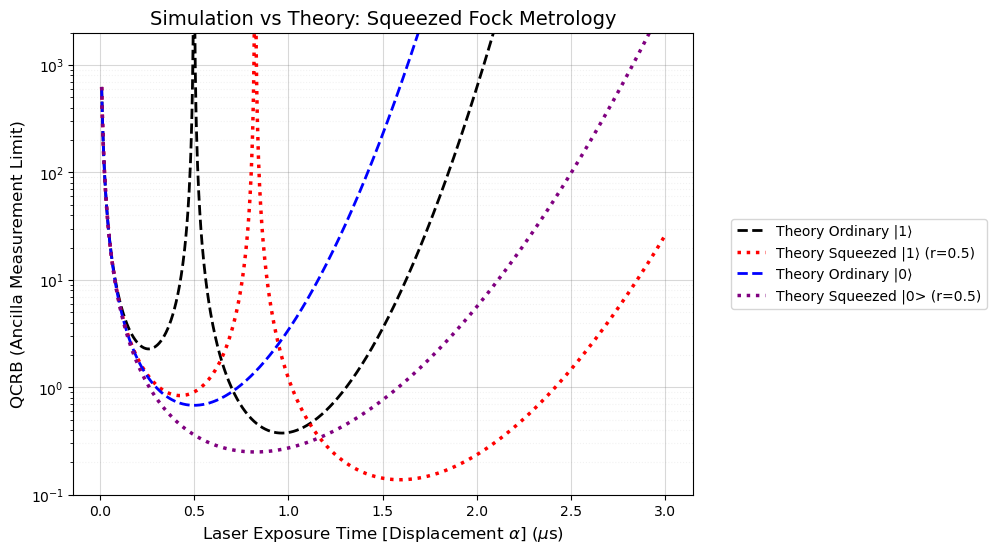

In [47]:
PyPlot.clf()
t_max = 3.0
alphas_theory = range(0.01, stop=t_max, length=1000)

x_norm = @. 4 * alphas_theory^2
qcrb_theory_1 = @. exp(x_norm) / (16 * alphas_theory^2 + 1e-15)

# 2. Theory for Squeezed Fock |1⟩
# Squeezing stretches both the envelope AND the Laguerre ripples by exp(-2r)
# Let x_sq = 4 * α^2 * exp(-2r). The formula is exp(x_sq) / (16α^2 * (1 - x_sq)^2)
suppression_factor = exp(-2 * r_squeeze)
x_sq = @. 4 * alphas_theory^2 * suppression_factor
qcrb_theory_sq_0 = @. exp(x_sq) / (16 * alphas_theory^2+ 1e-15)

# 1. Theory for Ordinary Fock |1⟩
# Let x = 4 * α^2. The formula is exp(x) / (16α^2 * (1 - x)^2)
x_norm = @. 4 * alphas_theory^2
qcrb_theory_1 = @. exp(x_norm) / (16 * alphas_theory^2 * (1 - x_norm)^2 + 1e-15)

# 2. Theory for Squeezed Fock |1⟩
# Squeezing stretches both the envelope AND the Laguerre ripples by exp(-2r)
# Let x_sq = 4 * α^2 * exp(-2r). The formula is exp(x_sq) / (16α^2 * (1 - x_sq)^2)
suppression_factor = exp(-2 * r_squeeze)
x_sq = @. 4 * alphas_theory^2 * suppression_factor
qcrb_theory_sq = @. exp(x_sq) / (16 * alphas_theory^2 * (1 - x_sq)^2 + 1e-15)

# Plot the pure analytical equations
PyPlot.plot(alphas_theory, qcrb_theory_1, "--", color="black", linewidth=2, label="Theory Ordinary |1⟩")
PyPlot.plot(alphas_theory, qcrb_theory_sq, ":", color="red", linewidth=2.5, label="Theory Squeezed |1⟩ (r=$r_squeeze)")

PyPlot.plot(alphas_theory, qcrb_theory_0, "--", color="blue", linewidth=2, label="Theory Ordinary |0⟩")
PyPlot.plot(alphas_theory, qcrb_theory_sq_0, ":", color="purple", linewidth=2.5, label="Theory Squeezed |0> (r=$r_squeeze)")

# ---------------------------------------------------------
# Plot Formatting
# ---------------------------------------------------------
PyPlot.yscale("log")
PyPlot.ylim(1e-1, 2e3) # Confidently constrain the Y-axis so infinities don't compress the graph

PyPlot.xlabel(L"Laser Exposure Time [Displacement $\alpha$] ($\mu$s)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Simulation vs Theory: Squeezed Fock Metrology", fontsize=14)

# Put legend in the lower left so it doesn't cover the data curves
PyPlot.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

Simulating Ordinary Vacuum |0⟩...
Beta: 0.01 μs, State: Vacuum, QCRB: 631.2804651034652
Beta: 0.06 μs, State: Vacuum, QCRB: 17.853317960472243
Beta: 0.11 μs, State: Vacuum, QCRB: 5.480696619445355
Beta: 0.16 μs, State: Vacuum, QCRB: 2.7366460232628054
Beta: 0.21 μs, State: Vacuum, QCRB: 1.7067531376906622
Beta: 0.26 μs, State: Vacuum, QCRB: 1.2222911786859958
Beta: 0.31 μs, State: Vacuum, QCRB: 0.9620008158741804
Beta: 0.36 μs, State: Vacuum, QCRB: 0.8140242674113498
Beta: 0.41 μs, State: Vacuum, QCRB: 0.730716001992581
Beta: 0.46 μs, State: Vacuum, QCRB: 0.689116207868187
Beta: 0.51 μs, State: Vacuum, QCRB: 0.6789473672891637
Beta: 0.56 μs, State: Vacuum, QCRB: 0.695545159072008
Beta: 0.61 μs, State: Vacuum, QCRB: 0.7385048533548646
Beta: 0.66 μs, State: Vacuum, QCRB: 0.8106020910282363
Beta: 0.71 μs, State: Vacuum, QCRB: 0.9183011534542179
Beta: 0.76 μs, State: Vacuum, QCRB: 1.071108067235525
Beta: 0.81 μs, State: Vacuum, QCRB: 1.2863343910699536
Beta: 0.86 μs, State: Vacuum, QCRB: 1

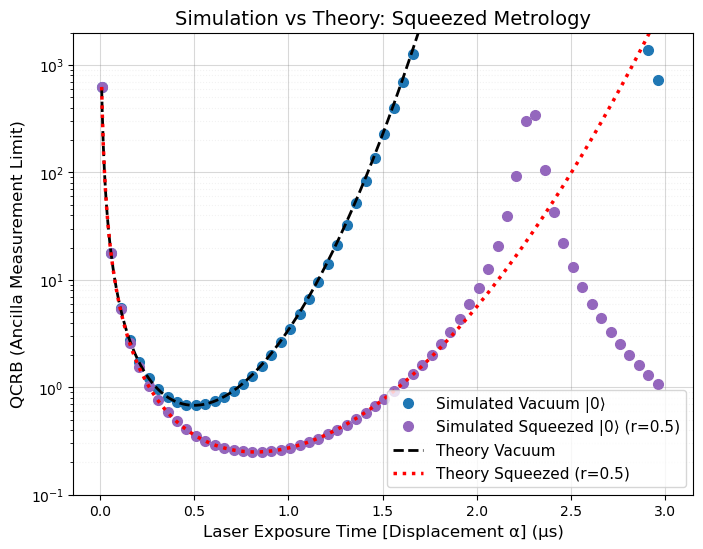

In [ ]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Squeezed vs Vacuum
# ---------------------------------------------------------
t_max = 3.0
time_steps = 0.01:0.05:t_max 
states = 0:1 
ψ_ion = normalize(ion["g"] - ion["e"])
d_alpha = 0.01

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

# Pre-build the signal operator once to save loop time
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, im * d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal

# Squeezing parameter
r_squeeze = 0.5

for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    if n == 0
        println("Simulating Ordinary Vacuum |0⟩...")
        ψ_mode = fockstate(sim_mode, 0)
        label_sim = "Simulated Vacuum |0⟩"
        color_sim = "tab:blue"
    else
        println("Simulating Squeezed Vacuum (r = $r_squeeze)...")
        # 1. Trick QuantumOptics into calculating the matrix
        temp_fock_basis = FockBasis(sim_mode.N)
        
        # 2. Squeeze in momentum (anti-squeeze in position)
        z = r_squeeze * exp(1im * pi) 
        S_fock = squeeze(temp_fock_basis, z) 
        
        # 3. Wrap it back into IonSim
        squeeze_op = DenseOperator(sim_mode, sim_mode, S_fock.data)
        vac = fockstate(sim_mode, 0)
        ψ_mode = squeeze_op * vac
        
        label_sim = "Simulated Squeezed |0⟩ (r=$r_squeeze)"
        color_sim = "tab:purple"
    end
    
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: Create the perturbed initial state
    ψ_initial_perturbed = D_system * ψ_initial
    
    for (j, t) in enumerate(time_steps)
        # 1. Base Trajectory (No Signal)
        sol1 = protocol(ψ_initial, 1, t)
        ancilla_base = ptrace(sol1, 2) 
        
        # 2. Perturbed Trajectory (Signal happened before SDF readout)
        sol2 = protocol(ψ_initial_perturbed, 1, t)
        ancilla_perturbed = ptrace(sol2, 2)
        
        # 3. Calculate true Ancilla QCRB
        qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[i, j] = qcrb
        println("Beta: ", round(t, digits=2), " μs, State: ", n==0 ? "Vacuum" : "Squeezed", ", QCRB: ", qcrb)
    end
    
    # Plot simulation as scatter dots
    PyPlot.plot(time_steps, qcrb_values, "o", color=color_sim, markersize=7, label=label_sim)
end

# ---------------------------------------------------------
# Analytical Theory Overlay
# ---------------------------------------------------------
# High-resolution X-axis to capture smooth curves
alphas_theory = range(0.01, stop=t_max, length=1000)

# 1. Theory for Ordinary Vacuum (r = 0)
# Formula: exp(4x^2) / (16x^2)
qcrb_theory_0 = @. exp(4 * alphas_theory^2) / (16 * alphas_theory^2 + 1e-15)

# 2. Theory for Squeezed Vacuum
# Because we used a phase of pi, the wavepacket is anti-squeezed (wider) in the X direction.
# This suppresses the wavepacket separation penalty by e^(-2r).
suppression_factor = exp(-2 * r_squeeze)
qcrb_theory_sq = @. exp(4 * alphas_theory^2 * suppression_factor) / (16 * alphas_theory^2 + 1e-15)

# Plot the pure analytical equations
PyPlot.plot(alphas_theory, qcrb_theory_0, "--", color="black", linewidth=2, label="Theory Vacuum")
PyPlot.plot(alphas_theory, qcrb_theory_sq, ":", color="red", linewidth=2.5, label="Theory Squeezed (r=$r_squeeze)")

# ---------------------------------------------------------
# Plot Formatting
# ---------------------------------------------------------
PyPlot.yscale("log")
PyPlot.ylim(1e-1, 2e3) # Confidently constrain the Y-axis so infinities don't compress the graph

PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Simulation vs Theory: Squeezed Metrology", fontsize=14)

# Put legend in the lower right so it doesn't cover the upper-left curves
PyPlot.legend(loc="lower right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

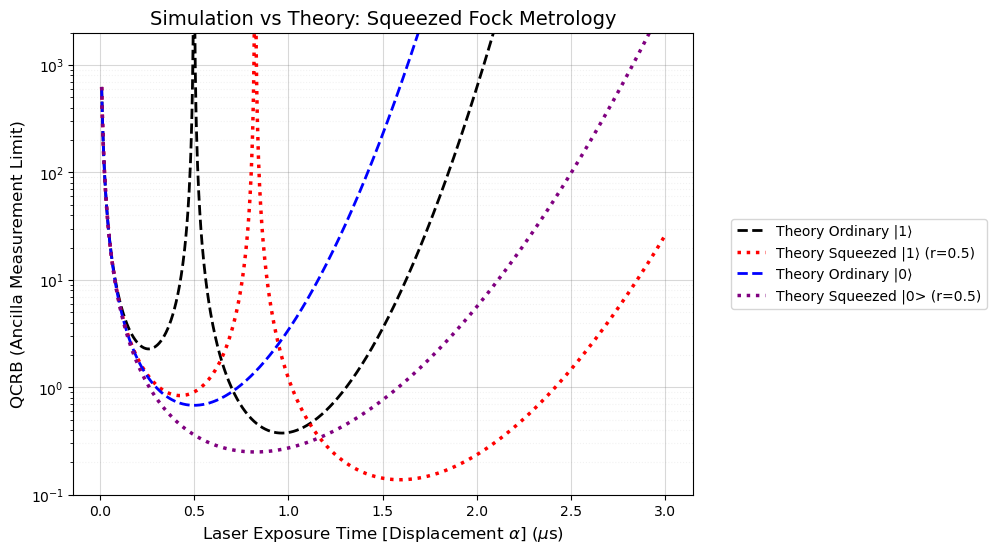

In [46]:
PyPlot.clf()
t_max = 3.0
alphas_theory = range(0.01, stop=t_max, length=1000)

x_norm = @. 4 * alphas_theory^2
qcrb_theory_1 = @. exp(x_norm) / (16 * alphas_theory^2 + 1e-15)

# 2. Theory for Squeezed Fock |1⟩
# Squeezing stretches both the envelope AND the Laguerre ripples by exp(-2r)
# Let x_sq = 4 * α^2 * exp(-2r). The formula is exp(x_sq) / (16α^2 * (1 - x_sq)^2)
suppression_factor = exp(-2 * r_squeeze)
x_sq = @. 4 * alphas_theory^2 * suppression_factor
qcrb_theory_sq_0 = @. exp(x_sq) / (16 * alphas_theory^2+ 1e-15)

# 1. Theory for Ordinary Fock |1⟩
# Let x = 4 * α^2. The formula is exp(x) / (16α^2 * (1 - x)^2)
x_norm = @. 4 * alphas_theory^2
qcrb_theory_1 = @. exp(x_norm) / (16 * alphas_theory^2 * (1 - x_norm)^2 + 1e-15)

# 2. Theory for Squeezed Fock |1⟩
# Squeezing stretches both the envelope AND the Laguerre ripples by exp(-2r)
# Let x_sq = 4 * α^2 * exp(-2r). The formula is exp(x_sq) / (16α^2 * (1 - x_sq)^2)
suppression_factor = exp(-2 * r_squeeze)
x_sq = @. 4 * alphas_theory^2 * suppression_factor
qcrb_theory_sq = @. exp(x_sq) / (16 * alphas_theory^2 * (1 - x_sq)^2 + 1e-15)

# Plot the pure analytical equations
PyPlot.plot(alphas_theory, qcrb_theory_1, "--", color="black", linewidth=2, label="Theory Ordinary |1⟩")
PyPlot.plot(alphas_theory, qcrb_theory_sq, ":", color="red", linewidth=2.5, label="Theory Squeezed |1⟩ (r=$r_squeeze)")

PyPlot.plot(alphas_theory, qcrb_theory_0, "--", color="blue", linewidth=2, label="Theory Ordinary |0⟩")
PyPlot.plot(alphas_theory, qcrb_theory_sq_0, ":", color="purple", linewidth=2.5, label="Theory Squeezed |0> (r=$r_squeeze)")

# ---------------------------------------------------------
# Plot Formatting
# ---------------------------------------------------------
PyPlot.yscale("log")
PyPlot.ylim(1e-1, 2e3) # Confidently constrain the Y-axis so infinities don't compress the graph

PyPlot.xlabel(L"Laser Exposure Time [Displacement $\alpha$] ($\mu$s)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Simulation vs Theory: Squeezed Fock Metrology", fontsize=14)

# Put legend in the lower left so it doesn't cover the data curves
PyPlot.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)